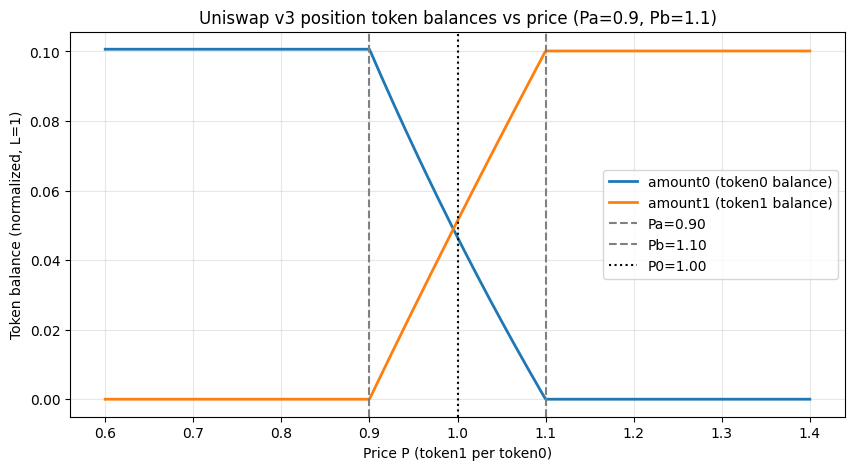

Start price P0=1.0, bounds: [0.9, 1.1]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Official references:
# Whitepaper (Uniswap v3): https://uniswap.org/whitepaper-v3.pdf
# Docs (Concentrated Liquidity): https://docs.uniswap.org/concepts/protocol/concentrated-liquidity

# ------------------------------
# Uniswap v3 concentrated liquidity formulas
# ------------------------------
# Let:
# P   - current price (token1 per token0)
# Pa  - lower price bound
# Pb  - upper price bound
# L   - liquidity
#
# In sqrt-price notation:
# sqrtP  = sqrt(P), sqrtPa = sqrt(Pa), sqrtPb = sqrt(Pb)
#
# Token balances for one position:
# amount0(P) =
#   L * (sqrtPb - sqrtPa) / (sqrtPa * sqrtPb),  P <= Pa
#   L * (sqrtPb - sqrtP)  / (sqrtP  * sqrtPb),  Pa < P < Pb
#   0,                                            P >= Pb
#
# amount1(P) =
#   0,                                            P <= Pa
#   L * (sqrtP - sqrtPa),                        Pa < P < Pb
#   L * (sqrtPb - sqrtPa),                       P >= Pb

P0 = 1.0           # start price
band = 0.1         # bounds += 0.1 around start price
Pa = P0 - band     # 0.9
Pb = P0 + band     # 1.1
L = 1.0            # normalized liquidity


def uniswap_v3_amounts(P, Pa, Pb, L=1.0):
    sqrtP = np.sqrt(P)
    sqrtPa = np.sqrt(Pa)
    sqrtPb = np.sqrt(Pb)

    amount0 = np.where(
        P <= Pa,
        L * (sqrtPb - sqrtPa) / (sqrtPa * sqrtPb),
        np.where(P < Pb, L * (sqrtPb - sqrtP) / (sqrtP * sqrtPb), 0.0),
    )

    amount1 = np.where(
        P <= Pa,
        0.0,
        np.where(P < Pb, L * (sqrtP - sqrtPa), L * (sqrtPb - sqrtPa)),
    )

    return amount0, amount1


# Price grid for visualization
prices = np.linspace(0.6, 1.4, 500)
amount0, amount1 = uniswap_v3_amounts(prices, Pa, Pb, L)

plt.figure(figsize=(10, 5))
plt.plot(prices, amount0, label="amount0 (token0 balance)", linewidth=2)
plt.plot(prices, amount1, label="amount1 (token1 balance)", linewidth=2)
plt.axvline(Pa, color="gray", linestyle="--", label=f"Pa={Pa:.2f}")
plt.axvline(Pb, color="gray", linestyle="--", label=f"Pb={Pb:.2f}")
plt.axvline(P0, color="black", linestyle=":", label=f"P0={P0:.2f}")
plt.title("Uniswap v3 position token balances vs price (Pa=0.9, Pb=1.1)")
plt.xlabel("Price P (token1 per token0)")
plt.ylabel("Token balance (normalized, L=1)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Start price P0={P0}, bounds: [{Pa}, {Pb}]")

In [14]:
# Compute starting balances from parameters:
# Given: start price P0 and exact start portfolio value V0
# Find: liquidity L and start balances amount0(P0), amount1(P0)

def solve_start_balances_from_token0(P0, Pa, Pb, start_value):
    if not (Pa < P0 < Pb):
        raise ValueError("P0 must be strictly inside (Pa, Pb) for this setup")
    if float(start_value) <= 0:
        raise ValueError("start_value must be > 0")

    sqrtP0 = np.sqrt(P0)
    sqrtPa = np.sqrt(Pa)
    sqrtPb = np.sqrt(Pb)

    # Inside range:
    # amount0(P0) = L * (sqrtPb - sqrtP0) / (sqrtP0 * sqrtPb)
    # amount1(P0) = L * (sqrtP0 - sqrtPa)
    # Value constraint at start:
    # start_value = amount0(P0) * P0 + amount1(P0)
    coef0 = (sqrtPb - sqrtP0) / (sqrtP0 * sqrtPb)
    coef1 = (sqrtP0 - sqrtPa)
    denom = coef0 * P0 + coef1
    if denom <= 0:
        raise ValueError("Invalid inputs: implied denominator must be > 0")

    L = float(start_value) / denom
    amount0_start = L * coef0
    amount1_start = L * coef1

    return L, amount0_start, amount1_start


start_value_target = 1

L_start, amount0_start, amount1_start = solve_start_balances_from_token0(
    P0=P0,
    Pa=Pa,
    Pb=Pb,
    start_value=start_value_target,
)

print("Start balances from parameters:")
print(f"P0={P0}, Pa={Pa}, Pb={Pb}")
print(f"start_value_target = {start_value_target:.10f}")
print(f"amount0_start = {amount0_start:.10f}")
print(f"amount1_start = {amount1_start:.10f}")
print(f"implied liquidity L = {L_start:.10f}")
print(f"check value = {amount0_start * P0 + amount1_start:.10f}")

Start balances from parameters:
P0=1.0, Pa=0.9, Pb=1.1
start_value_target = 1.0000000000
amount0_start = 0.4755795078
amount1_start = 0.5244204922
implied liquidity L = 10.2192945434
check value = 1.0000000000


In [15]:
# Balances at range boundaries Pa and Pb
# Use liquidity derived from the previous cell
L_used = L_start

amount0_Pa, amount1_Pa = uniswap_v3_amounts(np.array([Pa]), Pa, Pb, L_used)
amount0_Pb, amount1_Pb = uniswap_v3_amounts(np.array([Pb]), Pa, Pb, L_used)

print("Balances at range boundaries:")
print(f"Using liquidity L = {L_used:.10f}")
print(f"At Pa={Pa:.6f}: amount0={amount0_Pa[0]:.10f}, amount1={amount1_Pa[0]:.10f}")
print(f"At Pb={Pb:.6f}: amount0={amount0_Pb[0]:.10f}, amount1={amount1_Pb[0]:.10f}")

Balances at range boundaries:
Using liquidity L = 10.2192945434
At Pa=0.900000: amount0=1.0283672435, amount1=0.0000000000
At Pb=1.100000: amount0=0.0000000000, amount1=1.0232124880


In [16]:
# Portfolio value at key prices: bottom bound, start, top bound
# V(P) = amount0(P) * P + amount1(P)

L_used = L_start

price_btm = Pa
price_mid = P0
price_top = Pb

amount0_btm, amount1_btm = uniswap_v3_amounts(np.array([price_btm]), Pa, Pb, L_used)
amount0_mid, amount1_mid = uniswap_v3_amounts(np.array([price_mid]), Pa, Pb, L_used)
amount0_top, amount1_top = uniswap_v3_amounts(np.array([price_top]), Pa, Pb, L_used)

amount0_btm = amount0_btm[0]
amount1_btm = amount1_btm[0]
amount0_mid = amount0_mid[0]
amount1_mid = amount1_mid[0]
amount0_top = amount0_top[0]
amount1_top = amount1_top[0]

value_btm = amount0_btm * price_btm + amount1_btm
value_mid = amount0_mid * price_mid + amount1_mid
value_top = amount0_top * price_top + amount1_top

print("Portfolio values (V = token0 * price + token1):")
print(f"Using liquidity L = {L_used:.10f}")
print(f"btm={price_btm:.6f}: token0={amount0_btm:.10f}, token1={amount1_btm:.10f}, V={value_btm:.10f}")
print(f"mid={price_mid:.6f}: token0={amount0_mid:.10f}, token1={amount1_mid:.10f}, V={value_mid:.10f}")
print(f"top={price_top:.6f}: token0={amount0_top:.10f}, token1={amount1_top:.10f}, V={value_top:.10f}")

Portfolio values (V = token0 * price + token1):
Using liquidity L = 10.2192945434
btm=0.900000: token0=1.0283672435, token1=0.0000000000, V=0.9255305191
mid=1.000000: token0=0.4755795078, token1=0.5244204922, V=1.0000000000
top=1.100000: token0=0.0000000000, token1=1.0232124880, V=1.0232124880


In [17]:
# Returns relative to start portfolio value
# 100 * (top / start - 1)
# 100 * (btm / start - 1)

ret_top_pct = 100.0 * (value_top / value_mid - 1.0)
ret_btm_pct = 100.0 * (value_btm / value_mid - 1.0)

print("Returns (%), relative to start value:")
print(f"top vs start: {ret_top_pct:.10f}%")
print(f"btm vs start: {ret_btm_pct:.10f}%")

Returns (%), relative to start value:
top vs start: 2.3212487988%
btm vs start: -7.4469480874%


In [18]:
# Rebalance rule:
# - when price hits a boundary, remove liquidity
# - rebalance back to token0_target (same as start token0)
# - add liquidity again
# Assumption: no swap fees and no slippage.

token0_target = amount0_start  # start token0 level, usually 1.0

# ---------- TOP boundary (price_top) ----------
# Before rebalance at top: mostly/all token1, token0 is low.
# To restore token0 to target, sell token1 and buy token0.
token0_need_top = max(0.0, token0_target - amount0_top)
token1_sold_top = token0_need_top * price_top
token0_got_top = token0_need_top

amount0_after_top = amount0_top + token0_got_top
amount1_after_top = amount1_top - token1_sold_top
value_after_rebalance_top = amount0_after_top * price_top + amount1_after_top

# ---------- BOTTOM boundary (price_btm) ----------
# Before rebalance at bottom: mostly/all token0, token1 is low.
# To restore token0 to target, sell excess token0 and buy token1.
token0_excess_btm = max(0.0, amount0_btm - token0_target)
token0_sold_btm = token0_excess_btm
token1_got_btm = token0_sold_btm * price_btm

amount0_after_btm = amount0_btm - token0_sold_btm
amount1_after_btm = amount1_btm + token1_got_btm
value_after_rebalance_btm = amount0_after_btm * price_btm + amount1_after_btm

# ---------- PnL vs start ----------
pnl_top_abs = value_after_rebalance_top - value_mid
pnl_btm_abs = value_after_rebalance_btm - value_mid
pnl_top_pct = 100.0 * pnl_top_abs / value_mid
pnl_btm_pct = 100.0 * pnl_btm_abs / value_mid

print("Rebalance at boundaries to token0_target (no fee/slippage):")
print(f"start value = {value_mid:.10f}")
print("")

print("TOP boundary:")
print(
    f"  sold {token1_sold_top:.10f} token1 at price {price_top:.6f}, "
    f"got {token0_got_top:.10f} token0"
)
print(
    f"  after rebalance: token0={amount0_after_top:.10f}, "
    f"token1={amount1_after_top:.10f}"
)
print(
    f"  Value at price {price_top:.1f}: "
    f"{amount0_after_top:.10f} * {price_top:.1f} + {amount1_after_top:.10f} "
    f"= {value_after_rebalance_top:.10f}"
)
print(
    f"  PnL vs start={pnl_top_abs:.10f} ({pnl_top_pct:.10f}%)"
)
print("")

print("BOTTOM boundary:")
print(
    f"  sold {token0_sold_btm:.10f} token0 at price {price_btm:.6f}, "
    f"got {token1_got_btm:.10f} token1"
)
print(
    f"  after rebalance: token0={amount0_after_btm:.10f}, "
    f"token1={amount1_after_btm:.10f}"
)
print(
    f"  Value at price {price_btm:.1f}: "
    f"{amount0_after_btm:.10f} * {price_btm:.1f} + {amount1_after_btm:.10f} "
    f"= {value_after_rebalance_btm:.10f}"
)
print(
    f"  PnL vs start={pnl_btm_abs:.10f} ({pnl_btm_pct:.10f}%)"
)

Rebalance at boundaries to token0_target (no fee/slippage):
start value = 1.0000000000

TOP boundary:
  sold 0.5231374586 token1 at price 1.100000, got 0.4755795078 token0
  after rebalance: token0=0.4755795078, token1=0.5000750294
  Value at price 1.1: 0.4755795078 * 1.1 + 0.5000750294 = 1.0232124880
  PnL vs start=0.0232124880 (2.3212487988%)

BOTTOM boundary:
  sold 0.5527877357 token0 at price 0.900000, got 0.4975089621 token1
  after rebalance: token0=0.4755795078, token1=0.4975089621
  Value at price 0.9: 0.4755795078 * 0.9 + 0.4975089621 = 0.9255305191
  PnL vs start=-0.0744694809 (-7.4469480874%)


In [19]:
# Comparison against HOLD portfolio from start balances
# Prints MID / TOP / BTM in one unified format:
#   100*(value/_startvalue - 1)

_startvalue = amount0_start * price_mid + amount1_start

hold_mid = amount0_start * price_mid + amount1_start
hold_top = amount0_start * price_top + amount1_start
hold_btm = amount0_start * price_btm + amount1_start

lp_mid = value_mid
lp_top = value_top
lp_btm = value_btm

print("Start balances used:")
print(f"amount0_start = {amount0_start:.10f}")
print(f"amount1_start = {amount1_start:.10f}")
print(f"Start value: {_startvalue:.10f}")
print("")

# ---------- TOP ----------
print(f"TOP @ price {price_top:.1f}")
print(
    f"  Hold value: {amount0_start:.10f} * {price_top:.1f} + {amount1_start:.10f} = {hold_top:.10f}"
)
print(
    f"  Hold PnL vs start: 100*({hold_top:.10f}/{_startvalue:.10f} - 1) = "
    f"{100.0 * (hold_top / _startvalue - 1.0):.10f}%"
)
print(f"  LP value:   {lp_top:.10f}")
print(
    f"  LP PnL vs start:   100*({lp_top:.10f}/{_startvalue:.10f} - 1) = "
    f"{100.0 * (lp_top / _startvalue - 1.0):.10f}%"
)
print(
    f"  LP - Hold: {lp_top - hold_top:.10f} "
    f"({100.0 * ((lp_top - hold_top) / hold_top):.10f}% of Hold)"
)
print("")

# ---------- BTM ----------
print(f"BTM @ price {price_btm:.1f}")
print(
    f"  Hold value: {amount0_start:.10f} * {price_btm:.1f} + {amount1_start:.10f} = {hold_btm:.10f}"
)
print(
    f"  Hold PnL vs start: 100*({hold_btm:.10f}/{_startvalue:.10f} - 1) = "
    f"{100.0 * (hold_btm / _startvalue - 1.0):.10f}%"
)
print(f"  LP value:   {lp_btm:.10f}")
print(
    f"  LP PnL vs start:   100*({lp_btm:.10f}/{_startvalue:.10f} - 1) = "
    f"{100.0 * (lp_btm / _startvalue - 1.0):.10f}%"
)
print(
    f"  LP - Hold: {lp_btm - hold_btm:.10f} "
    f"({100.0 * ((lp_btm - hold_btm) / hold_btm):.10f}% of Hold)"
)

Start balances used:
amount0_start = 0.4755795078
amount1_start = 0.5244204922
Start value: 1.0000000000

TOP @ price 1.1
  Hold value: 0.4755795078 * 1.1 + 0.5244204922 = 1.0475579508
  Hold PnL vs start: 100*(1.0475579508/1.0000000000 - 1) = 4.7557950778%
  LP value:   1.0232124880
  LP PnL vs start:   100*(1.0232124880/1.0000000000 - 1) = 2.3212487988%
  LP - Hold: -0.0243454628 (-2.3240206207% of Hold)

BTM @ price 0.9
  Hold value: 0.4755795078 * 0.9 + 0.5244204922 = 0.9524420492
  Hold PnL vs start: 100*(0.9524420492/1.0000000000 - 1) = -4.7557950778%
  LP value:   0.9255305191
  LP PnL vs start:   100*(0.9255305191/1.0000000000 - 1) = -7.4469480874%
  LP - Hold: -0.0269115301 (-2.8255293975% of Hold)


In [20]:
# Expected LP return with full-probability formula:
# E[LP PnL] = 0.5 * LP_PnL_top + 0.5 * LP_PnL_btm

lp_pnl_top_pct = 100.0 * (lp_top / _startvalue - 1.0)
lp_pnl_btm_pct = 100.0 * (lp_btm / _startvalue - 1.0)

lp_pnl_top_abs = lp_top - _startvalue
lp_pnl_btm_abs = lp_btm - _startvalue

expected_lp_pnl_pct = 0.5 * lp_pnl_top_pct + 0.5 * lp_pnl_btm_pct
expected_lp_pnl_abs = 0.5 * lp_pnl_top_abs + 0.5 * lp_pnl_btm_abs

print("Expected LP PnL (p_top=0.5, p_btm=0.5):")
print(
    f"0.5 * ({lp_pnl_top_pct:.10f}%) + 0.5 * ({lp_pnl_btm_pct:.10f}%) "
    f"= {expected_lp_pnl_pct:.10f}%"
)
print(
    f"0.5 * ({lp_pnl_top_abs:.10f}) + 0.5 * ({lp_pnl_btm_abs:.10f}) "
    f"= {expected_lp_pnl_abs:.10f}"
)

Expected LP PnL (p_top=0.5, p_btm=0.5):
0.5 * (2.3212487988%) + 0.5 * (-7.4469480874%) = -2.5628496443%
0.5 * (0.0232124880) + 0.5 * (-0.0744694809) = -0.0256284964


In [21]:
# Put/Call hedge sizing for BTM+TOP so that expected PnL becomes 0
# Assumptions:
# - ideal options, no premium/fees
# - strike K at start price
# - two-point scenario: TOP and BTM with probabilities p_top / p_btm

# Inputs from previous cells
P_start = price_mid
P_top = price_top
P_btm = price_btm
K = P_start

p_top = 0.5
p_btm = 0.5

start_value = value_mid
lp_top = value_top
lp_btm = value_btm

# LP PnL in each scenario (absolute, in token1 units)
lp_pnl_top_abs = lp_top - start_value
lp_pnl_btm_abs = lp_btm - start_value

# Expected LP PnL before options
E_lp_abs = p_top * lp_pnl_top_abs + p_btm * lp_pnl_btm_abs
E_lp_pct = 100.0 * E_lp_abs / start_value

# Option payoff per 1 token0 notional in each relevant scenario
call_payoff_top_per_unit = max(P_top - K, 0.0)   # call helps on TOP
put_payoff_btm_per_unit = max(K - P_btm, 0.0)    # put helps on BTM

# Need expected option payoff = -E_lp_abs
required_option_ev = -E_lp_abs

print("LP expectation before options:")
print(f"  TOP PnL = {lp_pnl_top_abs:.10f}")
print(f"  BTM PnL = {lp_pnl_btm_abs:.10f}")
print(f"  E[LP PnL] = {E_lp_abs:.10f} ({E_lp_pct:.10f}%)")
print("")
print("Per-unit option payoffs:")
print(f"  call payoff at TOP per 1 notional = {call_payoff_top_per_unit:.10f}")
print(f"  put  payoff at BTM per 1 notional = {put_payoff_btm_per_unit:.10f}")
print("")

if required_option_ev <= 0:
    print("E[LP PnL] is already >= 0, no long put/call needed for zero expectation.")
else:
    print(f"Required expected payoff from options = {required_option_ev:.10f}")
    print("")

    # 1) Pure put solution (N_call = 0)
    if p_btm * put_payoff_btm_per_unit > 0:
        N_put_only = required_option_ev / (p_btm * put_payoff_btm_per_unit)
    else:
        N_put_only = np.nan

    # 2) Pure call solution (N_put = 0)
    if p_top * call_payoff_top_per_unit > 0:
        N_call_only = required_option_ev / (p_top * call_payoff_top_per_unit)
    else:
        N_call_only = np.nan

    # 3) Symmetric split solution (N_put = N_call = N_same)
    denom_same = p_btm * put_payoff_btm_per_unit + p_top * call_payoff_top_per_unit
    if denom_same > 0:
        N_same = required_option_ev / denom_same
    else:
        N_same = np.nan

    print("Solutions for E[LP PnL + options] = 0:")
    print(f"  Pure PUT : N_put={N_put_only:.10f}, N_call=0.0000000000")
    print(f"  Pure CALL: N_put=0.0000000000, N_call={N_call_only:.10f}")
    print(f"  Symmetric: N_put={N_same:.10f}, N_call={N_same:.10f}")
    print("")
    print("General family:")
    print("  p_btm*put_payoff*N_put + p_top*call_payoff*N_call = -E_lp_abs")
    print("  Choose any N_put >= 0, then:")
    if p_top * call_payoff_top_per_unit > 0:
        print(
            "  N_call = "
            f"({required_option_ev:.10f} - {p_btm * put_payoff_btm_per_unit:.10f}*N_put)"
            f" / {p_top * call_payoff_top_per_unit:.10f}"
        )

LP expectation before options:
  TOP PnL = 0.0232124880
  BTM PnL = -0.0744694809
  E[LP PnL] = -0.0256284964 (-2.5628496443%)

Per-unit option payoffs:
  call payoff at TOP per 1 notional = 0.1000000000
  put  payoff at BTM per 1 notional = 0.1000000000

Required expected payoff from options = 0.0256284964

Solutions for E[LP PnL + options] = 0:
  Pure PUT : N_put=0.5125699289, N_call=0.0000000000
  Pure CALL: N_put=0.0000000000, N_call=0.5125699289
  Symmetric: N_put=0.2562849644, N_call=0.2562849644

General family:
  p_btm*put_payoff*N_put + p_top*call_payoff*N_call = -E_lp_abs
  Choose any N_put >= 0, then:
  N_call = (0.0256284964 - 0.0500000000*N_put) / 0.0500000000


In [64]:
# Emulation
start_price = 1.0
band = 0.1
sign = True

start_value_target = 1

token0_balance = None
token1_balance = None

initial_token0_balance = None
initial_token1_balance = None

token0_added = 0.0
token1_added = 0.0
external_value_added = 0.0

# Realized IL proxy (user definition):
# step PnL at rebalance = value at exit boundary - start_value_target
realized_il_total = 0.0
realized_il_top = 0.0
realized_il_bottom = 0.0

current_price = start_price

for _ in range(1000):
    # Calculate prices
    price_lower = current_price * (1 - band)
    price_upper = current_price * (1 + band)

    # Invest exact start value into the pool
    liquidity, amount0_in_pool, amount1_in_pool = solve_start_balances_from_token0(
        P0=float(current_price),
        Pa=float(price_lower),
        Pb=float(price_upper),
        start_value=float(start_value_target),
    )

    # Initial balances
    if token0_balance is None:
        token0_balance = amount0_in_pool
        token1_balance = amount1_in_pool

        initial_token0_balance = token0_balance
        initial_token1_balance = token1_balance
    else:
        # Rebalance tokens.
        # Rule: swap only from excess balances (above required in-pool amounts),
        # then externally add the remaining deficit.

        # 1) Cover token0 deficit using only excess token1.
        excess_token1 = max(0.0, token1_balance - amount1_in_pool)
        if token0_balance < amount0_in_pool and excess_token1 > 0.0:
            need_token0 = amount0_in_pool - token0_balance
            buy_token0 = min(need_token0, excess_token1 / current_price)
            sell_token1 = buy_token0 * current_price

            token0_balance += buy_token0
            token1_balance -= sell_token1

        # 2) Cover token1 deficit using only excess token0.
        excess_token0 = max(0.0, token0_balance - amount0_in_pool)
        if token1_balance < amount1_in_pool and excess_token0 > 0.0:
            need_token1 = amount1_in_pool - token1_balance
            sell_token0 = min(excess_token0, need_token1 / current_price)
            buy_token1 = sell_token0 * current_price

            token0_balance -= sell_token0
            token1_balance += buy_token1

        # 3) External add for any remaining deficit.
        # Track added value at the moment of funding (token1 numeraire).
        if token0_balance < amount0_in_pool:
            delta_token0 = amount0_in_pool - token0_balance
            token0_added += delta_token0
            external_value_added += delta_token0 * current_price
            token0_balance = amount0_in_pool

        if token1_balance < amount1_in_pool:
            delta_token1 = amount1_in_pool - token1_balance
            token1_added += delta_token1
            external_value_added += delta_token1
            token1_balance = amount1_in_pool

    # Substract invested amounts from balances
    token0_balance -= amount0_in_pool
    token1_balance -= amount1_in_pool

    assert token0_balance >= 0.0, f'token0_balance={token0_balance}, amount0_in_pool={amount0_in_pool}'
    assert token1_balance >= 0.0, f'token1_balance={token1_balance}, amount1_in_pool={amount1_in_pool}'

    # Price moved
    exit_to_top = sign
    if exit_to_top:
        current_price = price_upper
    else:
        current_price = price_lower

    # Invert sign
    sign = not sign

    # Take out amounts from the pool
    amount0_out_arr, amount1_out_arr = uniswap_v3_amounts(
        np.array([float(current_price)]),
        float(price_lower),
        float(price_upper),
        float(liquidity),
    )

    amount0_out = float(amount0_out_arr[0])
    amount1_out = float(amount1_out_arr[0])

    # Realized IL (as realized PnL at rebalance boundary).
    # Positive on TOP, negative on BOTTOM for this strategy setup.
    step_exit_value = amount0_out * current_price + amount1_out
    step_realized_il = step_exit_value - start_value_target
    realized_il_total += step_realized_il
    if exit_to_top:
        realized_il_top += step_realized_il
    else:
        realized_il_bottom += step_realized_il

    # Add received balances
    token0_balance += amount0_out
    token1_balance += amount1_out

# Result
print(f'Initial token0 balance: {initial_token0_balance}')
print(f'Initial token1 balance: {initial_token1_balance}')
print(f'Start equity: {initial_token0_balance * start_price + initial_token1_balance}')
print()

print(f'Token0 balance: {token0_balance}')
print(f'Token1 balance: {token1_balance}')
end_equity_gross = token0_balance * current_price + token1_balance
print(f'End equity (gross): {end_equity_gross}')
print()

print(f'Token0 added: {token0_added}')
print(f'Token1 added: {token1_added}')
print(f'External value added (at funding time): {external_value_added}')
print()

start_equity = initial_token0_balance * start_price + initial_token1_balance
end_equity_net = end_equity_gross - external_value_added
pnl_net = end_equity_net - start_equity

print(f'End equity (net of funding): {end_equity_net}')
print(f'Net PnL: {pnl_net}')
print()
print(f'Realized IL total (value): {realized_il_total}')
print(f'Realized IL TOP (value): {realized_il_top}')
print(f'Realized IL BOTTOM (value): {realized_il_bottom}')
    

Initial token0 balance: 0.47557950778450886
Initial token1 balance: 0.5244204922154911
Start equity: 1.0

Token0 balance: 140.86186862543738
Token1 balance: 0.023212487988289565
End equity (gross): 0.9487430071146135

Token0 added: 0.0
Token1 added: 25.577239449807752
External value added (at funding time): 25.577239449807752

End equity (net of funding): -24.628496442693137
Net PnL: -25.628496442693137

Realized IL total (value): -25.62849644269366
Realized IL TOP (value): 11.606243994144691
Realized IL BOTTOM (value): -37.23474043683813
